<a href="https://colab.research.google.com/github/adanmiguel/fraud-detection-ml/blob/main/Fraude_Canastas_Adan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas

In [ ]:
!pip install dtreeviz  # versión 2.2.2

In [ ]:
# Bibliotecas para manipulación de datos y cálculos
import numpy as np
import pandas as pd

# Funciones específicas de Scikit-learn para machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Para visualizar el árbol de decisión
import graphviz
import dtreeviz

# Bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para montar Google Drive en Colab
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

 Funciones Auxiliares

In [ ]:
def describe_datos(df):
    """
    Función para describir un DataFrame de pandas.

    Devuelve:
    --------
    DataFrame
        Devuelve un DataFrame con la descripción de cada columna, incluyendo:
    (1) Tipo de columna, (2) Número de valores nulos, (3) Porcentaje de valores nulos
    (4) Número de valores únicos y (5) Valores únicos
    """

    unicos =[]
    for col in df:
        unicos.append(df[col].unique())
    unicos = pd.Series(unicos, index=df.columns)
    descripcion = pd.concat(
        [
            df.dtypes,
            df.isna().sum(),
            round(df.isna().sum()/len(df)*100, 1),
            df.nunique(),
            unicos
        ],
        axis=1
    )

    descripcion.columns = ['dtypes', 'null', '%null', 'nunique', 'unique']
    return descripcion

def plot_distribucion_clases(y):
    """
    Función para visualizar la distribución de clases en la variable objetivo.
    """
    plt.figure(figsize=(10, 6))
    conteo = y.value_counts()
    colores = ['skyblue', 'salmon']
    etiquetas = ['No Fraude', 'Fraude']

    plt.bar(etiquetas, conteo.values, color=colores, edgecolor='black', alpha=0.7)
    plt.title('Distribución de la Variable Objetivo (Fraude vs No Fraude)', fontsize=14)
    plt.xlabel('Clase', fontsize=12)
    plt.ylabel('Cantidad de Observaciones', fontsize=12)
    plt.grid(True, alpha=0.3)

    for i, v in enumerate(conteo.values):
        plt.text(i, v + max(conteo.values)*0.01, str(v), ha='center', fontsize=12)

    plt.tight_layout()
    plt.show()

def crear_variables_binarias(X):
    """
    Transforma cada columna en una variable binaria que indica presencia (1)
    o ausencia (0) de un artículo en la canasta.
    """
    return X.applymap(lambda x: 1 if x > 0 else 0)

def calcular_suma_coordenadas(X):
    """
    Calcula la suma de las coordenadas en cada registro.
    Esta será la nueva variable objetivo para el modelo de regresión.
    """
    return X.sum(axis=1)

# Reto I Lectura de Datos, Preprocesamiento y Exploracion

In [ ]:
# 1. Montar Google Drive para acceder a los archivos almacenados
drive.mount('/content/drive')

# 2. Cargar el dataset desde Google Drive
print("=== CARGA DE DATOS ===")
ruta = '/content/drive/MyDrive/Bourbaki/1. ML-AI/5.2  Examen 1/Examen1/FraudeCanastas.csv'
df = pd.read_csv(ruta)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== CARGA DE DATOS ===


In [ ]:
print(f"Tamaño del conjunto de datos: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\nPrimeras filas del dataset:")


Tamaño del conjunto de datos: 9319 filas x 2457 columnas

Primeras filas del dataset:


In [ ]:
df.head()



,ID,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag
0,130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1299,649.500000,1299,0.0,1.0
1,195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3,3,4119,1373.000000,2470,0.0,1.0
2,217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,2806,1403.000000,2799,7.0,1.0
3,552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1206,603.000000,1199,7.0,1.0
4,854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,19,27,1807,66.925926,195,4.0,1.0


In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Columns: 2457 entries, ID to fraud_flag
dtypes: float64(2452), int64(5)
memory usage: 174.7 MB


In [ ]:
describe_datos(df)



,dtypes,null,%null,nunique,unique
ID,int64,0,0.0,9319,"[130, 195, 217, 552, 854, 855, 856, 941, 1157,..."
APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,float64,0,0.0,2,"[0.0, 1000.0]"
AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,float64,0,0.0,2,"[0.0, 20.0]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,float64,0,0.0,8,"[0.0, 125.0, 119.0, 120.0, 500.0, 129.0, 109.0..."
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,float64,0,0.0,8,"[0.0, 109.0, 100.0, 105.0, 104.0, 99.0, 119.0,..."
...,...,...,...,...,...
costo_total,int64,0,0.0,1639,"[1299, 4119, 2806, 1206, 1807, 1263, 942, 1199..."
costo_medio_item,float64,0,0.0,2034,"[649.5, 1373.0, 1403.0, 603.0, 66.925925925925..."
costo_item_max,int64,0,0.0,540,"[1299, 2470, 2799, 1199, 195, 280, 938, 929, 1..."
costo_item_min,float64,0,0.0,528,"[0.0, 7.0, 4.0, 1249.0, 25.0, 2470.0, 999.0, 1..."


In [ ]:
# 4. Identificar variable objetivo (última columna)
target_col = df.columns[-1]
print(f"\nVariable objetivo identificada: '{target_col}'")

# 5. Verificar si las clases están desbalanceadas
print(f"\n=== DISTRIBUCIÓN DE CLASES ===")
distribucion = df[target_col].value_counts(normalize=True)
print("Conteo de clases:")
print(df[target_col].value_counts())
print(f"\nProporciones:")
print(distribucion)


Variable objetivo identificada: 'fraud_flag'

=== DISTRIBUCIÓN DE CLASES ===
Conteo de clases:
fraud_flag
0.0    8000
1.0    1319
Name: count, dtype: int64

Proporciones:
fraud_flag
0.0    0.858461
1.0    0.141539
Name: proportion, dtype: float64


Exploración


=== EXPLORACIÓN DE DATOS ===


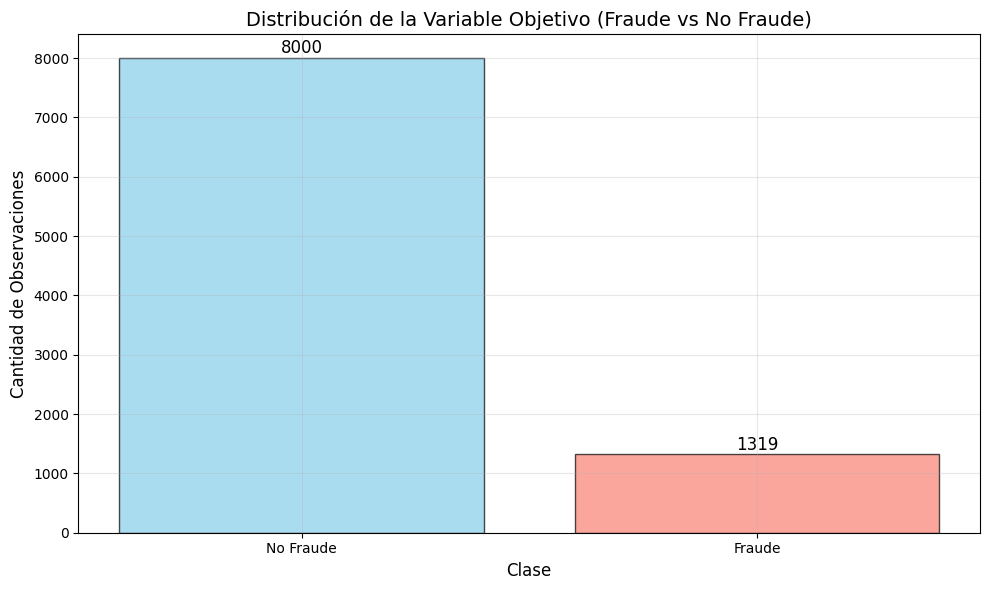


=== SEPARACIÓN DE DATOS PARA RETO I ===
Características (X): (9319, 2456)
Variable objetivo (y): (9319,)

=== ESTADÍSTICAS DESCRIPTIVAS DE CARACTERÍSTICAS ===
                  ID  APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90  \
count    9319.000000                                   9319.000000   
mean    58763.568409                                      0.107308   
std     33714.628042                                     10.358941   
min        45.000000                                      0.000000   
25%     29529.000000                                      0.000000   
50%     58489.000000                                      0.000000   
75%     88902.500000                                      0.000000   
max    115942.000000                                   1000.000000   

       AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H  \
count                                        9319.000000                                 
mean                         

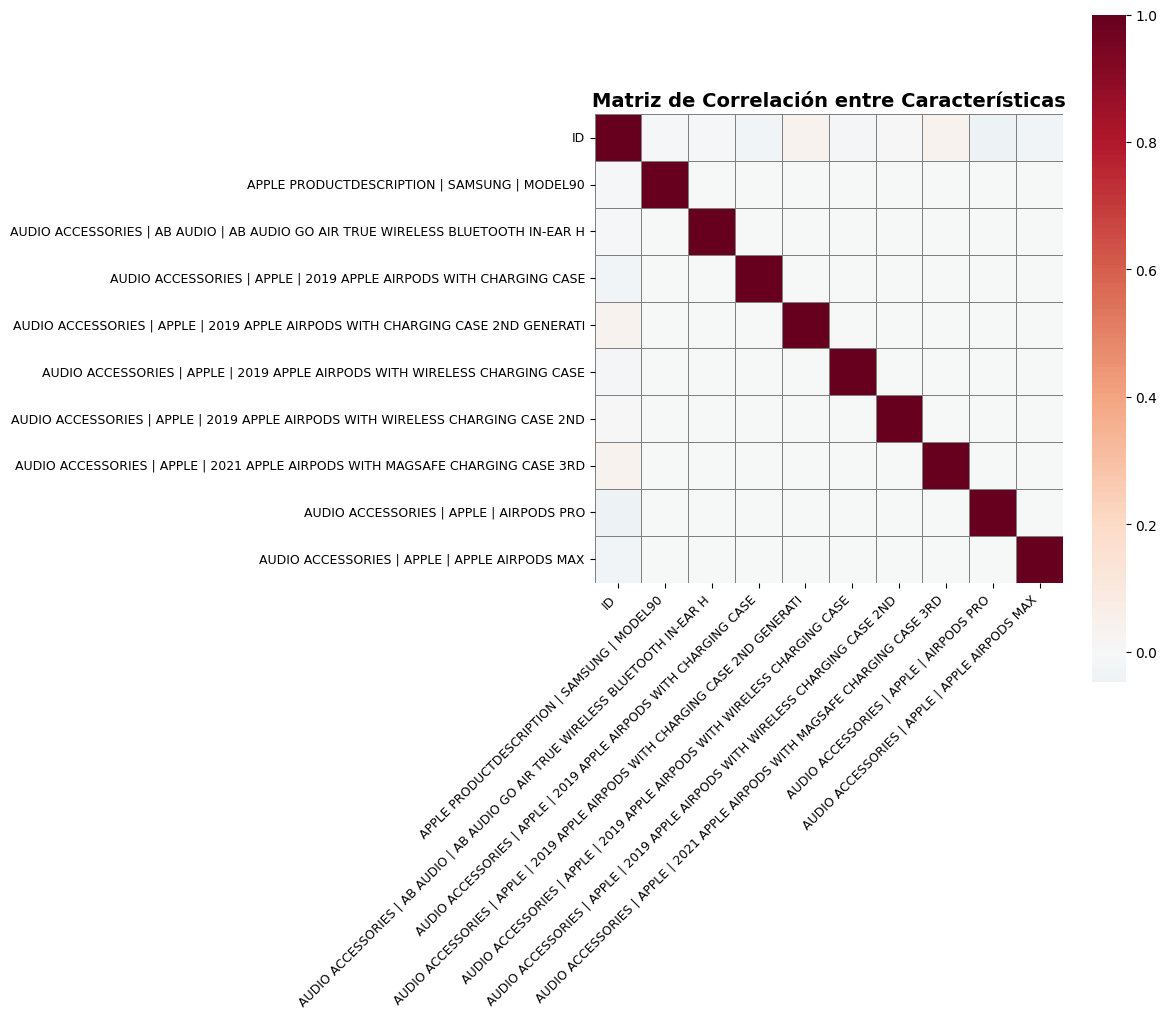

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== EXPLORACIÓN DE DATOS ===")

# ------------------------------------------------
# 1. Distribución de clases
# ------------------------------------------------
plot_distribucion_clases(df[target_col])

# ------------------------------------------------
# 2. Separar X e y
# ------------------------------------------------
y = df[target_col]
X = df.drop(columns=[target_col])

print("\n=== SEPARACIÓN DE DATOS PARA RETO I ===")
print(f"Características (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")

# ------------------------------------------------
# 3. Estadísticas descriptivas
# ------------------------------------------------
print("\n=== ESTADÍSTICAS DESCRIPTIVAS DE CARACTERÍSTICAS ===")
print(X.describe())

# ------------------------------------------------
# 4. MATRIZ DE CORRELACIÓN (TODOS LOS CUADROS COLOREADOS)
# ------------------------------------------------
if X.shape[1] > 10:
    print("\n=== CORRELACIÓN ENTRE LAS PRIMERAS 10 CARACTERÍSTICAS ===")
    X_corr = X.iloc[:, :10]
else:
    print("\n=== MATRIZ DE CORRELACIÓN ===")
    X_corr = X

corr_matrix = X_corr.corr()

# Tamaño dinámico
fig_size = max(12, corr_matrix.shape[1] * 1.2)

plt.figure(figsize=(fig_size, fig_size))

sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    square=True,          # 🔴 CLAVE: celdas cuadradas
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"shrink": 0.8},
    annot=False           # evita saturación
)

plt.title(
    "Matriz de Correlación entre Características",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


# RETO II - Cuantificación de Fraudes

Preparación de Datos para Modelado

In [ ]:
print("\n" + "="*70)
print("RETO I: PREPARACIÓN DE DATOS PARA DETECCIÓN DE FRAUDES")
print("="*70)

# 1. Crear subconjuntos de entrenamiento y prueba
print("\n=== DIVISIÓN DE DATOS PARA CLASIFICACIÓN ===")
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    shuffle=True,
                                                    stratify=y,
                                                    random_state=42)

# Información sobre los conjuntos creados
print("CONJUNTO DE ENTRENAMIENTO")
print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print('Proporción de fraudes en entrenamiento: {:7.3f}%'.format(y_train.mean()*100), '\n')

print("CONJUNTO DE PRUEBA")
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
print('Proporción de fraudes en prueba: {:7.3f}%'.format(y_test.mean()*100))

# 2. Verificar que la proporción se mantuvo
print("\n=== VERIFICACIÓN DE ESTRATIFICACIÓN ===")
print("Proporción en datos originales: {:.2%}".format(y.mean()))
print("Proporción en entrenamiento: {:.2%}".format(y_train.mean()))
print("Proporción en prueba: {:.2%}".format(y_test.mean()))


RETO I: PREPARACIÓN DE DATOS PARA DETECCIÓN DE FRAUDES

=== DIVISIÓN DE DATOS PARA CLASIFICACIÓN ===
CONJUNTO DE ENTRENAMIENTO
X_train:  (6523, 2456)
y_train:  (6523,)
Proporción de fraudes en entrenamiento:  14.150% 

CONJUNTO DE PRUEBA
X_test:  (2796, 2456)
y_test:  (2796,)
Proporción de fraudes en prueba:  14.163%

=== VERIFICACIÓN DE ESTRATIFICACIÓN ===
Proporción en datos originales: 14.15%
Proporción en entrenamiento: 14.15%
Proporción en prueba: 14.16%


Árbol de Decisión - Entrenamiento y Evaluación


RETO I: ÁRBOL DE DECISIÓN PARA DETECCIÓN DE FRAUDES

=== MODELO INICIAL (SIN LIMITAR PROFUNDIDAD) ===
La profundidad del árbol es: 48
Exactitud conjunto de entrenamiento: 100.00%
Exactitud conjunto de prueba: 86.02% 

=== EXPERIMENTO CON DIFERENTES PROFUNDIDADES ===


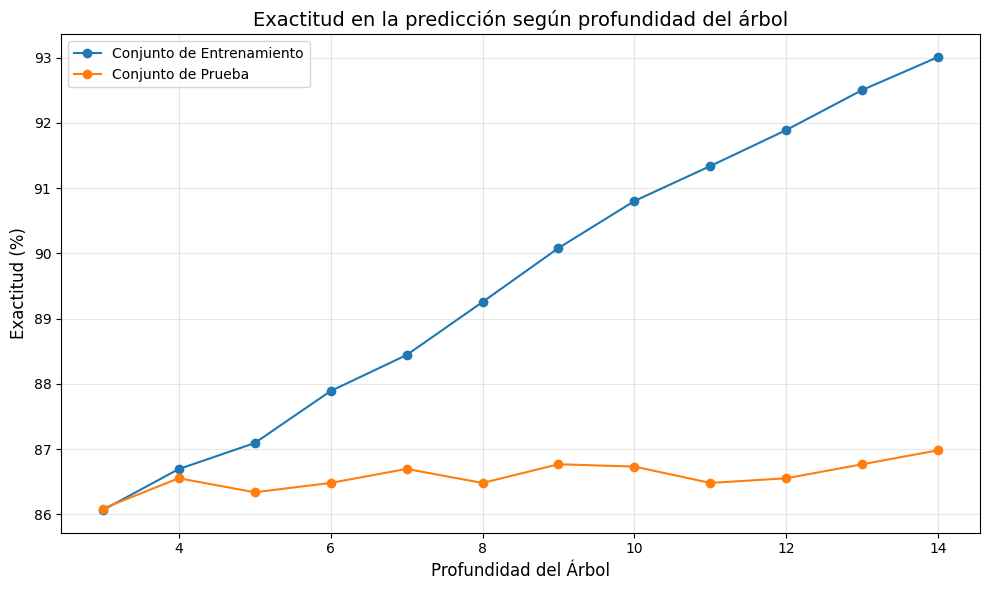

Tabla de exactitud por profundidad:
    Entrenamiento  Prueba
3           86.06   86.09
4           86.69   86.55
5           87.09   86.34
6           87.89   86.48
7           88.44   86.70
8           89.25   86.48
9           90.08   86.77
10          90.80   86.73
11          91.34   86.48
12          91.89   86.55
13          92.50   86.77
14          93.01   86.98

Profundidad óptima encontrada: 14
Exactitud máxima en prueba: 86.98%

=== MODELO CON PROFUNDIDAD ÓPTIMA (14) ===
Exactitud en entrenamiento: 93.01%
Exactitud en prueba: 86.98%


In [ ]:
print("\n" + "="*70)
print("RETO I: ÁRBOL DE DECISIÓN PARA DETECCIÓN DE FRAUDES")
print("="*70)

# 1. Entrenamiento inicial con profundidad None
print("\n=== MODELO INICIAL (SIN LIMITAR PROFUNDIDAD) ===")
profundidad = None

# Entrenamiento del modelo inicial
clasificador = DecisionTreeClassifier(max_depth=profundidad,
                                      criterion="entropy",
                                      random_state=42)
clasificador.fit(X_train, y_train)
print(f"La profundidad del árbol es: {clasificador.get_depth()}")

# Predicción y evaluación sobre conjunto de entrenamiento
y_pred_train = clasificador.predict(X_train)
exactitud_train = accuracy_score(y_train, y_pred_train)*100
print("Exactitud conjunto de entrenamiento: {:4.2f}%".format(exactitud_train))

# Predicción y evaluación sobre conjunto de prueba
y_pred_test = clasificador.predict(X_test)
exactitud_test = accuracy_score(y_test, y_pred_test)*100
print("Exactitud conjunto de prueba: {:4.2f}%".format(exactitud_test), '\n')

# 2. Entrenamiento con diferentes niveles de profundidad
print("=== EXPERIMENTO CON DIFERENTES PROFUNDIDADES ===")
clf = {}
exactitud_train_dict = {}
exactitud_test_dict = {}

# Probar diferentes profundidades
profundidades = range(3, 15)  # Rango ajustado según complejidad del dataset

for p in profundidades:
    # Entrenamiento del modelo con profundidad p
    clf[p] = DecisionTreeClassifier(max_depth=p,
                                     criterion="entropy",
                                     random_state=42).fit(X_train, y_train)

    # Predicción y evaluación sobre conjunto de entrenamiento
    y_pred_train_p = clf[p].predict(X_train)
    exactitud_train_dict[p] = accuracy_score(y_train, y_pred_train_p)*100

    # Predicción y evaluación sobre conjunto de prueba
    y_pred_test_p = clf[p].predict(X_test)
    exactitud_test_dict[p] = accuracy_score(y_test, y_pred_test_p)*100

# Crear DataFrame con resultados
exactitud_df = pd.DataFrame({
    'Entrenamiento': exactitud_train_dict,
    'Prueba': exactitud_test_dict
})

# Visualizar resultados
fig, ax = plt.subplots(figsize=(10, 6))
exactitud_df.plot.line(ax=ax, marker='o')
ax.set_title('Exactitud en la predicción según profundidad del árbol', fontsize=14)
ax.set_xlabel('Profundidad del Árbol', fontsize=12)
ax.set_ylabel('Exactitud (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(['Conjunto de Entrenamiento', 'Conjunto de Prueba'])
plt.tight_layout()
plt.show()

# Mostrar tabla de resultados
print("Tabla de exactitud por profundidad:")
print(exactitud_df.round(2))

# 3. Encontrar profundidad óptima
profundidad_optima = exactitud_df['Prueba'].idxmax()
print(f"\nProfundidad óptima encontrada: {profundidad_optima}")
print(f"Exactitud máxima en prueba: {exactitud_df.loc[profundidad_optima, 'Prueba']:.2f}%")

# 4. Modelo con profundidad óptima
model = clf[profundidad_optima]
print(f"\n=== MODELO CON PROFUNDIDAD ÓPTIMA ({profundidad_optima}) ===")
print(f"Exactitud en entrenamiento: {exactitud_df.loc[profundidad_optima, 'Entrenamiento']:.2f}%")
print(f"Exactitud en prueba: {exactitud_df.loc[profundidad_optima, 'Prueba']:.2f}%")

# Visualización del Árbol de Decisión

Importancia de Variables


=== VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN ===
Árbol de decisión exportado como 'arbol_decision_fraude.png'
Visualizando primeros 3 niveles de 14 totales


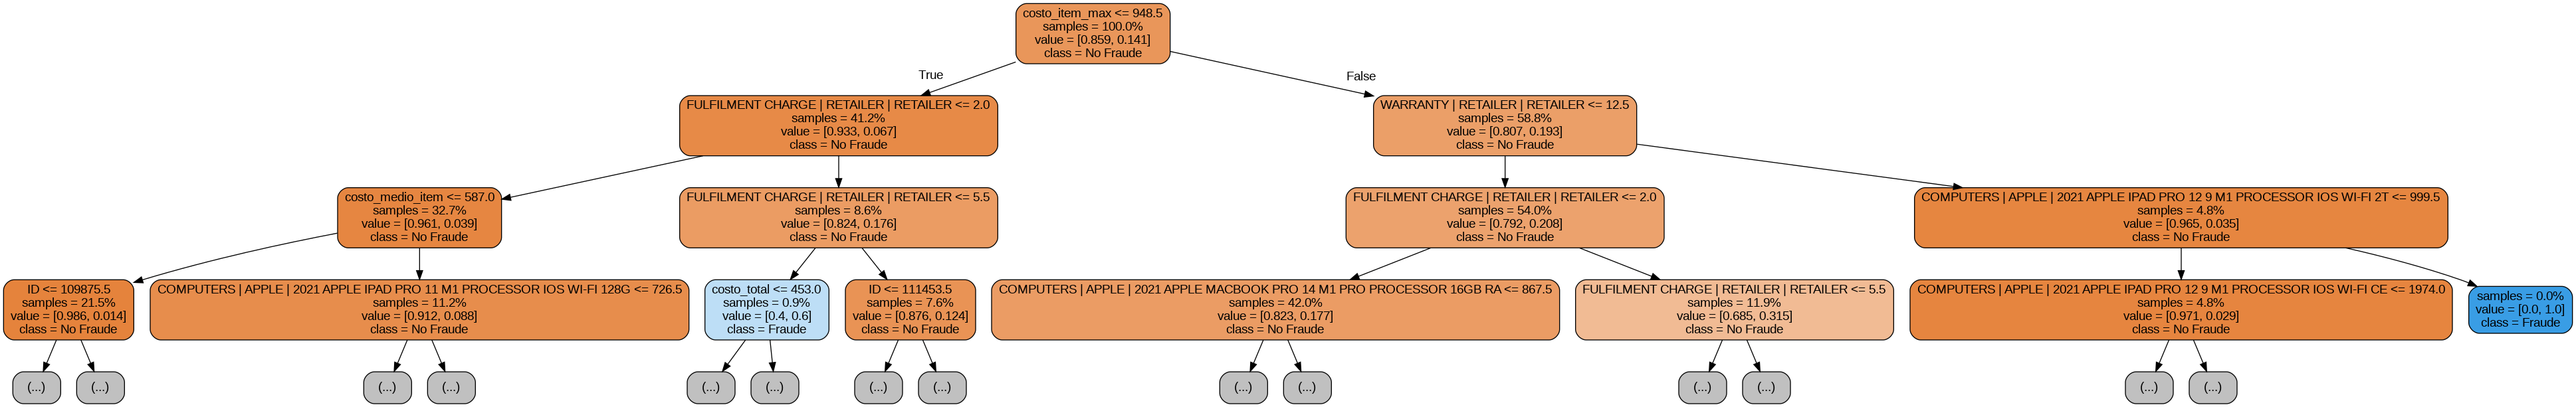


--- Intento de visualización con dtreeviz ---
dtreeviz no está instalado: cannot import name 'dtreeviz' from 'dtreeviz.trees' (/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py)
Instalando dtreeviz...
No se pudo instalar dtreeviz: cannot import name 'dtreeviz' from 'dtreeviz.trees' (/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py)

--- Información estructural del árbol ---
Profundidad total del árbol: 14
Número de nodos: 683
Número de hojas: 342
Características usadas en la raíz: costo_item_max


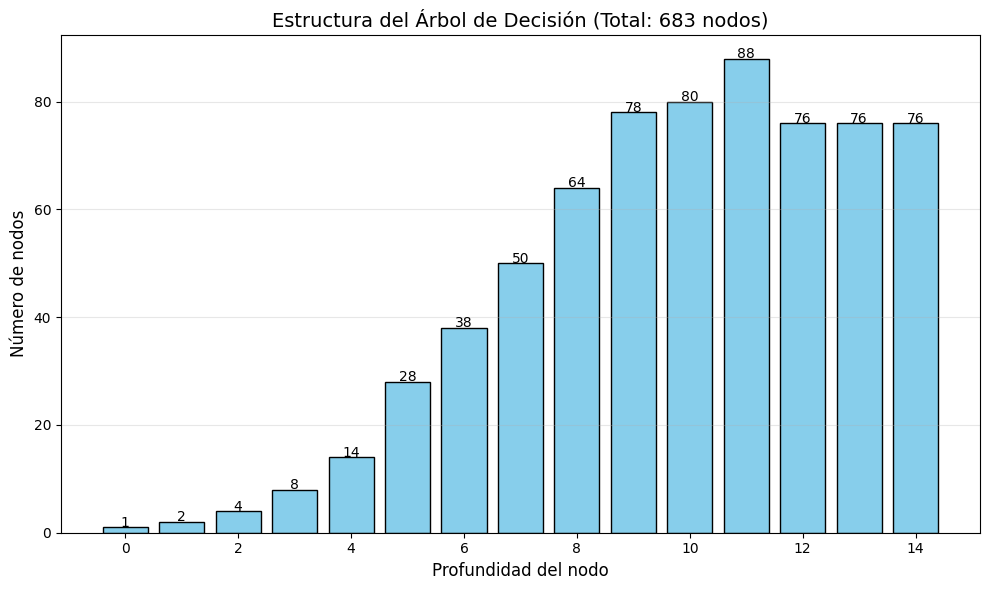


--- Reglas de decisión importantes ---
Analizando las primeras decisiones del árbol:

Reglas de decisión más importantes:
1. Si costo_item_max <= 948.5000
2. Si FULFILMENT CHARGE | RETAILER | RETAILER <= 2.0000
3. Si costo_medio_item <= 587.0000
4. Si ID <= 109875.5000
5. Si TELEPHONES, FAX MACHINES & TWO-WAY RADIOS | SAMSUNG | SAMSUNG GALAXY S21 SMARTPHONE <= 409.5000
6. Si COMPUTER PERIPHERALS ACCESSORIES | APPLE | APPLE WATCH SERIES 7 GPS 45MM PRODUCT RED ALUMINIU <= 199.5000
7. Si COMPUTER PERIPHERALS ACCESSORIES | SAMSUNG | SAMSUNG GALAXY WATCH 4 CLASSIC 4G CELLULAR 42MM ST <= 194.5000
8. Si costo_item_min <= 474.0000
9. Si COMPUTERS | APPLE | 2020 APPLE IPAD AIR 10.9" <= 694.0000
10. Si TELEPHONES, FAX MACHINES & TWO-WAY RADIOS | APPLE | APPLE IPHONE SE <= 439.0000

VISUALIZACIÓN COMPLETADA


In [ ]:
print("\n=== VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN ===")

# 1. Exportar árbol como archivo .dot para visualización (siempre intentar, incluso si es profundo)
try:
    # Exportar árbol completo o limitado
    max_visual_depth = min(3, profundidad_optima)  # Mostrar máximo 3 niveles para visualización

    dot_data = export_graphviz(model,  # Usar el modelo óptimo
                              feature_names=X.columns,
                              class_names=['No Fraude', 'Fraude'],
                              max_depth=max_visual_depth,  # Limitar profundidad para visualización
                              rounded=True,
                              filled=True,
                              proportion=True,  # Mostrar proporciones en lugar de conteos
                              impurity=False,   # Ocultar impureza para simplificar
                              label='all')      # Mostrar todas las etiquetas

    graph = graphviz.Source(dot_data, format='png')

    # Guardar el archivo
    graph.render('arbol_decision_fraude', cleanup=True)  # cleanup=True elimina archivos temporales
    print(f"Árbol de decisión exportado como 'arbol_decision_fraude.png'")
    print(f"Visualizando primeros {max_visual_depth} niveles de {profundidad_optima} totales")

    # También mostrar directamente en el notebook si es posible
    try:
        from IPython.display import display, Image
        display(Image(graph.render(format='png')))
    except:
        print("Nota: Para visualización interactiva, ejecutar en notebook con graphviz instalado")

except Exception as e:
    print(f"Error al exportar árbol: {e}")
    print("Instalando graphviz si es necesario...")

    # Intentar instalar graphviz si no está disponible
    try:
        import subprocess
        subprocess.run(['apt-get', 'update'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'graphviz'], check=False)
        print("Graphviz instalado. Intentando nuevamente...")

        # Reintentar después de instalar
        dot_data = export_graphviz(model,
                                  feature_names=X.columns,
                                  class_names=['No Fraude', 'Fraude'],
                                  max_depth=3,
                                  rounded=True,
                                  filled=True)

        graph = graphviz.Source(dot_data, format='png')
        graph.render('arbol_decision_fraude')
        print("Árbol exportado exitosamente después de instalar graphviz")
    except Exception as e2:
        print(f"No se pudo instalar graphviz: {e2}")

# 2. Visualización alternativa con dtreeviz (corrección del error)
print("\n--- Intento de visualización con dtreeviz ---")
try:
    # CORRECCIÓN: Importar correctamente dtreeviz
    from dtreeviz.trees import dtreeviz

    # Crear visualización
    viz = dtreeviz(model,
                   X_train,
                   y_train,
                   target_name='Fraude',
                   feature_names=list(X_train.columns),
                   class_names=['No Fraude', 'Fraude'],
                   title=f"Árbol de Decisión para Detección de Fraude (Profundidad: {profundidad_optima})",
                   orientation='TD',  # TD = Top-Down, LR = Left-Right
                   show_node_labels=True,
                   fancy=True,
                   histtype='bar',  # 'bar' o 'strip'
                   max_depth=3)     # Limitar profundidad para visualización

    # Mostrar la visualización
    viz.view()
    print("Visualización dtreeviz generada exitosamente")

    # También intentar guardar como archivo
    try:
        viz.save("arbol_fraude_dtreeviz.svg")
        print("Visualización guardada como 'arbol_fraude_dtreeviz.svg'")
    except Exception as save_error:
        print(f"No se pudo guardar el archivo: {save_error}")

except ImportError as ie:
    print(f"dtreeviz no está instalado: {ie}")
    print("Instalando dtreeviz...")

    try:
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "dtreeviz"])

        # Reintentar después de instalar
        from dtreeviz.trees import dtreeviz
        viz = dtreeviz(model,
                       X_train,
                       y_train,
                       target_name='Fraude',
                       feature_names=list(X_train.columns),
                       class_names=['No Fraude', 'Fraude'])
        viz.view()
        print("dtreeviz instalado y visualización generada exitosamente")
    except Exception as install_error:
        print(f"No se pudo instalar dtreeviz: {install_error}")

except Exception as e:
    print(f"Error con dtreeviz: {e}")
    print("Intentando visualización simplificada...")

    # Visualización alternativa más simple
    try:
        # Crear una versión simplificada del árbol para visualización
        tree_simple = DecisionTreeClassifier(max_depth=3, random_state=42)
        tree_simple.fit(X_train.iloc[:, :10], y_train)  # Usar solo primeras 10 características

        dot_data_simple = export_graphviz(tree_simple,
                                         feature_names=X.columns[:10],
                                         class_names=['No Fraude', 'Fraude'],
                                         rounded=True,
                                         filled=True)

        graph_simple = graphviz.Source(dot_data_simple, format='png')
        graph_simple.render('arbol_simplificado_fraude')
        print("Árbol simplificado exportado como 'arbol_simplificado_fraude.png'")

    except Exception as simple_error:
        print(f"No se pudo crear visualización simplificada: {simple_error}")

# 3. Visualización adicional: Mostrar estructura del árbol de otra manera
print("\n--- Información estructural del árbol ---")
print(f"Profundidad total del árbol: {model.get_depth()}")
print(f"Número de nodos: {model.tree_.node_count}")
print(f"Número de hojas: {model.get_n_leaves()}")
print(f"Características usadas en la raíz: {X.columns[model.tree_.feature[0]]}")

# Crear gráfico de la estructura del árbol
try:
    # Calcular número de nodos por nivel
    from collections import Counter
    node_depths = []

    def get_node_depths(tree, node_id=0, depth=0):
        if node_id == -1:
            return
        node_depths.append(depth)
        get_node_depths(tree, tree.children_left[node_id], depth + 1)
        get_node_depths(tree, tree.children_right[node_id], depth + 1)

    get_node_depths(model.tree_)

    # Contar nodos por profundidad
    depth_counts = Counter(node_depths)
    depths = sorted(depth_counts.keys())
    counts = [depth_counts[d] for d in depths]

    # Graficar
    plt.figure(figsize=(10, 6))
    plt.bar(depths, counts, color='skyblue', edgecolor='black')
    plt.xlabel('Profundidad del nodo', fontsize=12)
    plt.ylabel('Número de nodos', fontsize=12)
    plt.title(f'Estructura del Árbol de Decisión (Total: {model.tree_.node_count} nodos)', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')

    # Añadir etiquetas
    for i, (depth, count) in enumerate(zip(depths, counts)):
        plt.text(depth, count + 0.1, str(count), ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

except Exception as struct_error:
    print(f"No se pudo crear visualización estructural: {struct_error}")

# 4. Visualización de reglas de decisión importantes
print("\n--- Reglas de decisión importantes ---")
print("Analizando las primeras decisiones del árbol:")

# Función para extraer reglas importantes
def extract_important_rules(tree_model, feature_names, max_rules=5):
    tree = tree_model.tree_
    feature = tree.feature
    threshold = tree.threshold

    important_rules = []

    # Analizar los primeros nodos (más importantes)
    for i in range(min(max_rules, tree.node_count)):
        if feature[i] != -2:  # -2 indica nodo hoja
            feat_name = feature_names[feature[i]]
            thresh = threshold[i]
            important_rules.append((feat_name, thresh))

    return important_rules

try:
    rules = extract_important_rules(model, X.columns, max_rules=10)
    print("\nReglas de decisión más importantes:")
    for i, (feature, threshold) in enumerate(rules, 1):
        print(f"{i}. Si {feature} <= {threshold:.4f}")

except Exception as rule_error:
    print(f"No se pudieron extraer reglas: {rule_error}")

print("\n" + "="*60)
print("VISUALIZACIÓN COMPLETADA")
print("="*60)


=== IMPORTANCIA DE VARIABLES PARA DETECCIÓN ===


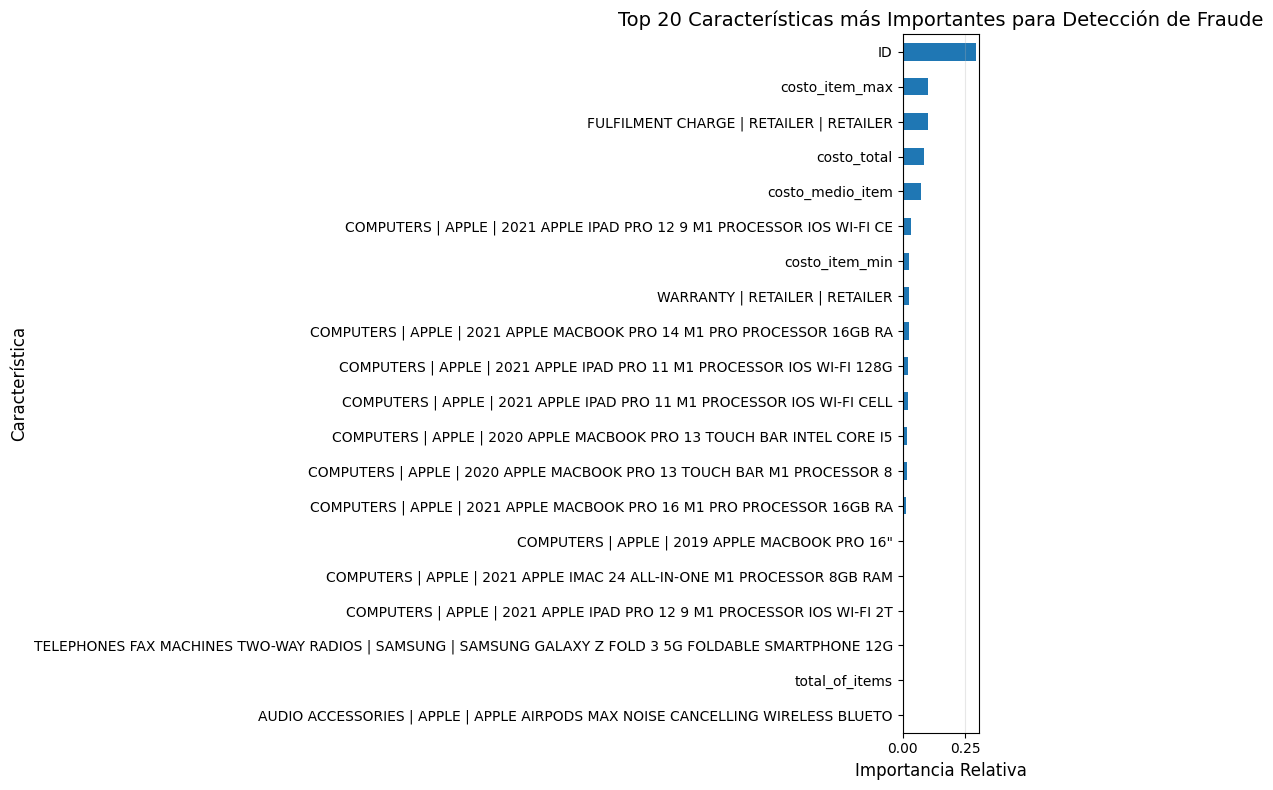

Top 10 características más importantes para detección:
 1. COMPUTERS | APPLE | 2021 APPLE IPAD PRO 11 M1 PROCESSOR IOS WI-FI 128G: 0.0208
 2. COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 14 M1 PRO PROCESSOR 16GB RA: 0.0249
 3. WARRANTY | RETAILER | RETAILER: 0.0253
 4. costo_item_min                : 0.0274
 5. COMPUTERS | APPLE | 2021 APPLE IPAD PRO 12 9 M1 PROCESSOR IOS WI-FI CE: 0.0326
 6. costo_medio_item              : 0.0724
 7. costo_total                   : 0.0864
 8. FULFILMENT CHARGE | RETAILER | RETAILER: 0.1008
 9. costo_item_max                : 0.1016
10. ID                            : 0.2912


In [ ]:
print("\n=== IMPORTANCIA DE VARIABLES PARA DETECCIÓN ===")

importancia = pd.Series(model.feature_importances_,
                       index=X.columns.values)

# Ordenar por importancia
importancia = importancia.sort_values()

# Visualizar top 20 características
top_n = min(20, len(importancia))
plt.figure(figsize=(10, 8))
importancia.tail(top_n).plot(kind='barh')
plt.title(f'Top {top_n} Características más Importantes para Detección de Fraude', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Mostrar top 10 características más importantes
print("Top 10 características más importantes para detección:")
top_10 = importancia.tail(10)
for i, (caracteristica, valor) in enumerate(top_10.items(), 1):
    print(f"{i:2d}. {caracteristica:30s}: {valor:.4f}")

# Matriz de Confusión y Métricas Detalladas


=== EVALUACIÓN DETALLADA DEL MODELO DE CLASIFICACIÓN ===


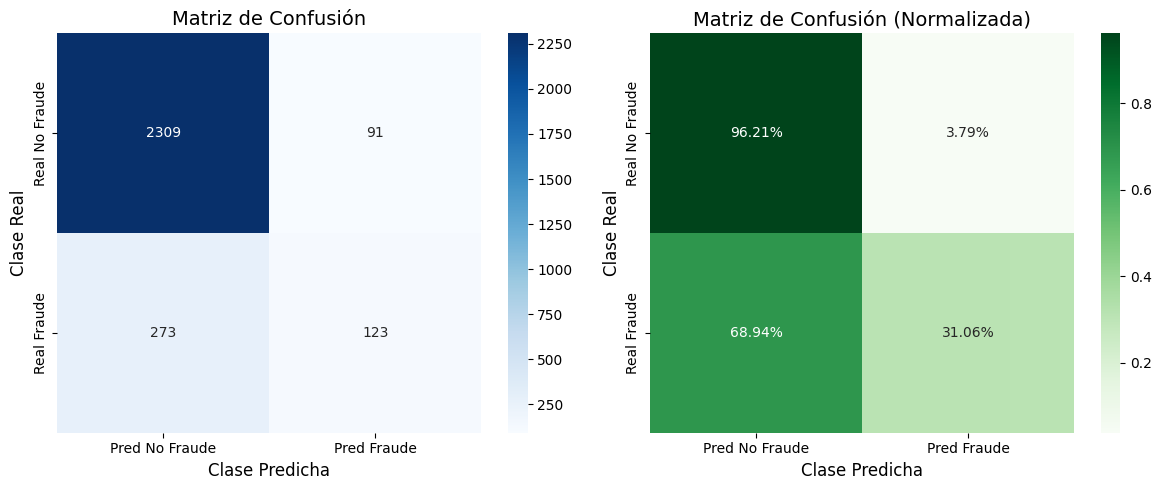


REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

   No Fraude       0.89      0.96      0.93      2400
      Fraude       0.57      0.31      0.40       396

    accuracy                           0.87      2796
   macro avg       0.73      0.64      0.67      2796
weighted avg       0.85      0.87      0.85      2796


=== MÉTRICAS CLAVE ===
Exactitud (Accuracy): 0.870
Precisión para Fraude: 0.575
Recall para Fraude: 0.311
F1-Score para Fraude: 0.403


In [ ]:
print("\n=== EVALUACIÓN DETALLADA DEL MODELO DE CLASIFICACIÓN ===")

# 1. Matriz de confusión
y_pred = model.predict(X_test)
confusion_mat = confusion_matrix(y_test, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión numérica
sns.heatmap(confusion_mat,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Pred No Fraude', 'Pred Fraude'],
            yticklabels=['Real No Fraude', 'Real Fraude'],
            ax=ax1)
ax1.set_title('Matriz de Confusión', fontsize=14)
ax1.set_ylabel('Clase Real', fontsize=12)
ax1.set_xlabel('Clase Predicha', fontsize=12)

# Matriz de confusión normalizada
confusion_mat_norm = confusion_mat.astype('float') / confusion_mat.sum(axis=1)[:, np.newaxis]
sns.heatmap(confusion_mat_norm,
            annot=True,
            fmt='.2%',
            cmap='Greens',
            xticklabels=['Pred No Fraude', 'Pred Fraude'],
            yticklabels=['Real No Fraude', 'Real Fraude'],
            ax=ax2)
ax2.set_title('Matriz de Confusión (Normalizada)', fontsize=14)
ax2.set_ylabel('Clase Real', fontsize=12)
ax2.set_xlabel('Clase Predicha', fontsize=12)

plt.tight_layout()
plt.show()

# 2. Reporte de clasificación detallado
print("\nREPORTE DE CLASIFICACIÓN DETALLADO:")
reporte = classification_report(y_test, y_pred, target_names=['No Fraude', 'Fraude'], output_dict=True)
print(classification_report(y_test, y_pred, target_names=['No Fraude', 'Fraude']))

# 3. Mostrar métricas clave
print("\n=== MÉTRICAS CLAVE ===")
print(f"Exactitud (Accuracy): {reporte['accuracy']:.3f}")
print(f"Precisión para Fraude: {reporte['Fraude']['precision']:.3f}")
print(f"Recall para Fraude: {reporte['Fraude']['recall']:.3f}")
print(f"F1-Score para Fraude: {reporte['Fraude']['f1-score']:.3f}")

Ajuste de Umbrales para Minimizar Errores


=== CURVA ROC Y ANÁLISIS DE UMBRALES ===


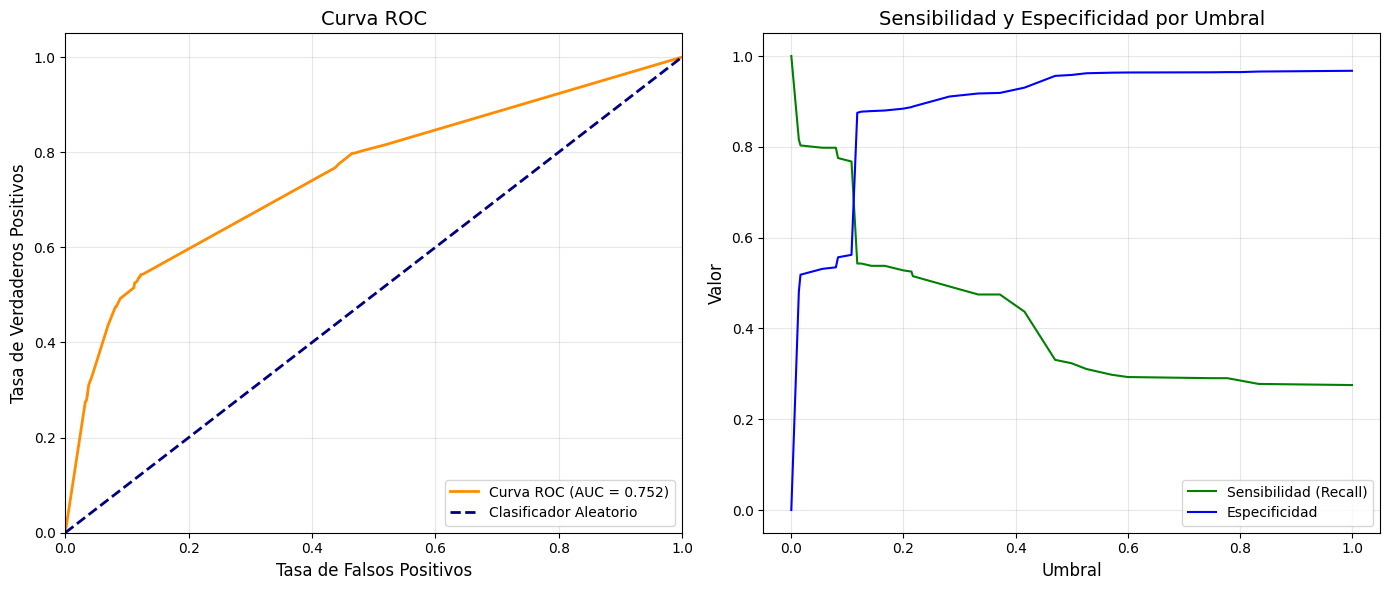


Área bajo la curva ROC (AUC): 0.752
Interpretación del AUC:
✓ Capacidad discriminativa aceptable

Umbral óptimo según distancia a (0,1): 0.125
Sensibilidad en umbral óptimo: 0.543
Especificidad en umbral óptimo: 0.877


In [ ]:
print("\n=== CURVA ROC Y ANÁLISIS DE UMBRALES ===")

from sklearn.metrics import RocCurveDisplay, roc_curve, auc

# 1. Calcular probabilidades
y_prob = model.predict_proba(X_test)[:, 1]

# 2. Calcular curva ROC
fpr, tpr, umbrales_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 3. Graficar curva ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Curva ROC
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax1.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax1.set_title('Curva ROC', fontsize=14)
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Sensibilidad y Especificidad por umbral
especificidad = 1 - fpr
ax2.plot(umbrales_roc[1:], tpr[1:], label='Sensibilidad (Recall)', color='green')
ax2.plot(umbrales_roc[1:], especificidad[1:], label='Especificidad', color='blue')
ax2.set_xlabel('Umbral', fontsize=12)
ax2.set_ylabel('Valor', fontsize=12)
ax2.set_title('Sensibilidad y Especificidad por Umbral', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nÁrea bajo la curva ROC (AUC): {roc_auc:.3f}")
print("Interpretación del AUC:")
if roc_auc >= 0.9:
    print("✓ Excelente capacidad discriminativa")
elif roc_auc >= 0.8:
    print("✓ Buena capacidad discriminativa")
elif roc_auc >= 0.7:
    print("✓ Capacidad discriminativa aceptable")
else:
    print("✗ Capacidad discriminativa pobre")

# 4. Encontrar umbral óptimo (punto más cercano a (0,1))
distancias = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
umbral_optimo_idx = np.argmin(distancias)
umbral_optimo = umbrales_roc[umbral_optimo_idx]

print(f"\nUmbral óptimo según distancia a (0,1): {umbral_optimo:.3f}")
print(f"Sensibilidad en umbral óptimo: {tpr[umbral_optimo_idx]:.3f}")
print(f"Especificidad en umbral óptimo: {especificidad[umbral_optimo_idx]:.3f}")

Curva ROC y Área bajo la Curva


RETO II: TRANSFORMACIÓN A VARIABLES BINARIAS Y PREPARACIÓN DE DATOS

OBJETIVO DEL RETO II:
Transformaremos cada columna en las características en una variable binaria
que únicamente indica la presencia o ausencia de un artículo en la canasta.

La variable objetivo será la suma de las coordenadas en cada registro de la
base de datos con la que comenzamos.

El objetivo es construir un modelo de regresión que prediga el valor del
fraude que se ha cometido.


=== TRANSFORMACIÓN DE CARACTERÍSTICAS A BINARIAS ===
Transformando cada valor > 0 en 1 (presencia) y 0 en 0 (ausencia)...
Forma de características binarias: (9319, 2456)

Ejemplo de transformación (primeras 5 filas, primeras 5 columnas):
Antes de transformar:
    ID  APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90  \
0  130                                           0.0   
1  195                                           0.0   
2  217                                           0.0   
3  552                                           0.0   

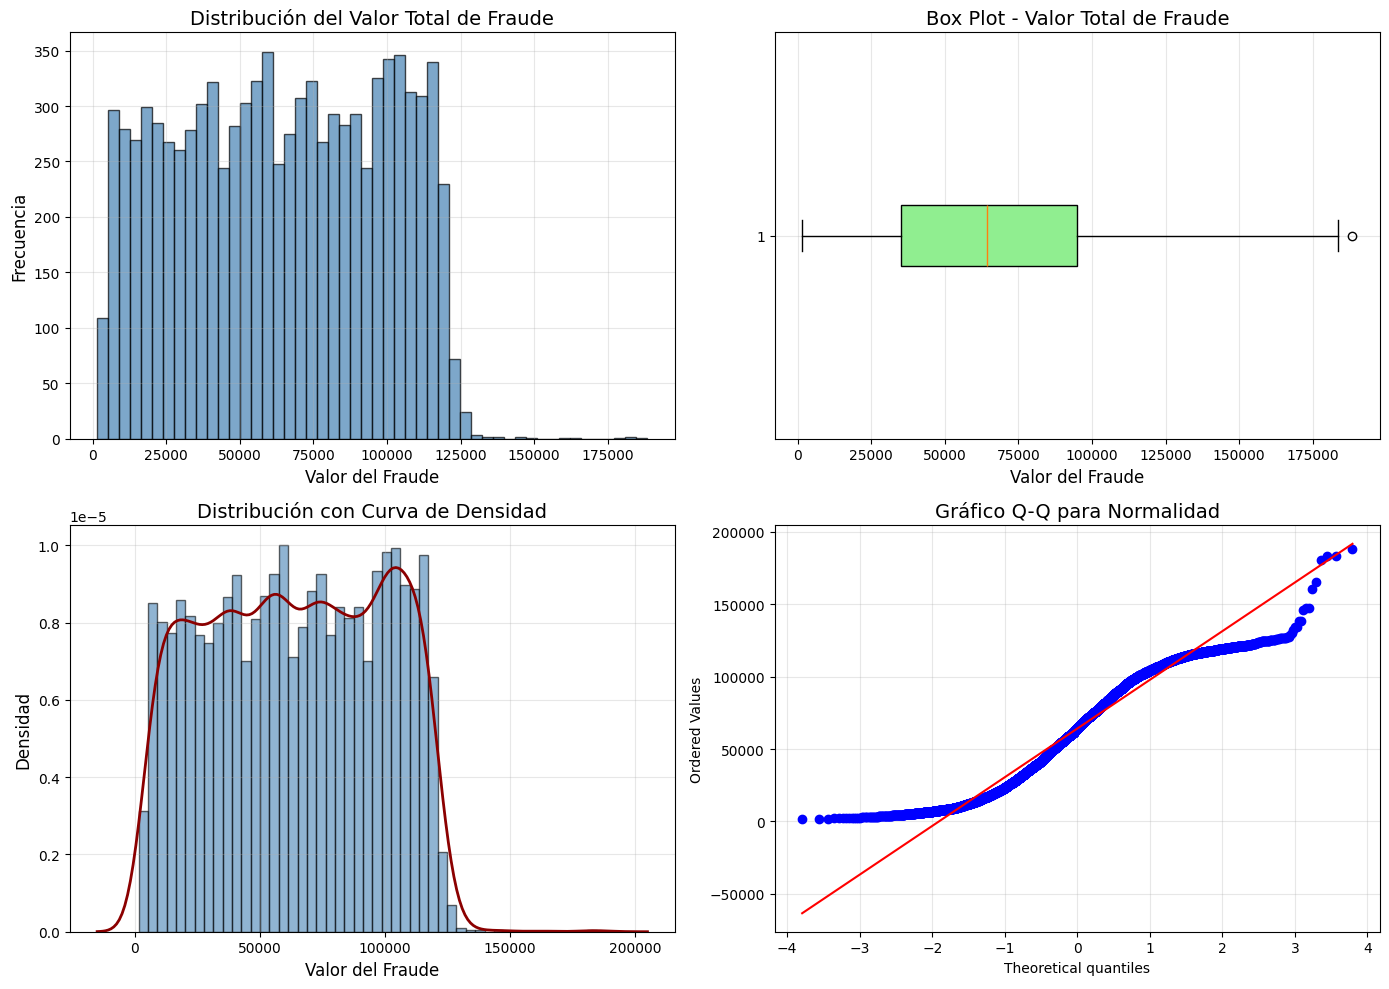


=== ANÁLISIS DE OUTLIERS ===
Límite inferior para outliers: -54533.54
Límite superior para outliers: 184352.12
Número de outliers detectados: 1 (0.01%)
Valor mínimo de outliers: 188453.00
Valor máximo de outliers: 188453.00


In [ ]:
print("\n" + "="*70)
print("RETO II: TRANSFORMACIÓN A VARIABLES BINARIAS Y PREPARACIÓN DE DATOS")
print("="*70)

print("""
OBJETIVO DEL RETO II:
Transformaremos cada columna en las características en una variable binaria
que únicamente indica la presencia o ausencia de un artículo en la canasta.

La variable objetivo será la suma de las coordenadas en cada registro de la
base de datos con la que comenzamos.

El objetivo es construir un modelo de regresión que prediga el valor del
fraude que se ha cometido.
""")

# 1. Transformar características a variables binarias
print("\n=== TRANSFORMACIÓN DE CARACTERÍSTICAS A BINARIAS ===")
print("Transformando cada valor > 0 en 1 (presencia) y 0 en 0 (ausencia)...")

X_binary = crear_variables_binarias(X)
print(f"Forma de características binarias: {X_binary.shape}")

# Mostrar ejemplo de transformación
print("\nEjemplo de transformación (primeras 5 filas, primeras 5 columnas):")
print("Antes de transformar:")
print(X.iloc[:5, :5])
print("\nDespués de transformar:")
print(X_binary.iloc[:5, :5])

# 2. Calcular nueva variable objetivo
print("\n=== CÁLCULO DE NUEVA VARIABLE OBJETIVO ===")
print("Calculando la suma de todas las coordenadas en cada registro...")

y_sum = calcular_suma_coordenadas(X)
print(f"Forma de nueva variable objetivo: {y_sum.shape}")

# 3. Análisis descriptivo de la nueva variable objetivo
print("\n=== ANÁLISIS DE LA NUEVA VARIABLE OBJETIVO ===")
print("Estadísticas descriptivas del valor total del fraude:")
print(y_sum.describe())

# Calcular percentiles para mejor entendimiento
percentiles = [0, 25, 50, 75, 90, 95, 99, 100]
for p in percentiles:
    valor = np.percentile(y_sum, p)
    print(f"Percentil {p:3d}%: {valor:.2f}")

# 4. Visualizar distribución del valor del fraude
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
axes[0, 0].hist(y_sum, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribución del Valor Total de Fraude', fontsize=14)
axes[0, 0].set_xlabel('Valor del Fraude', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Boxplot
axes[0, 1].boxplot(y_sum, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen'))
axes[0, 1].set_title('Box Plot - Valor Total de Fraude', fontsize=14)
axes[0, 1].set_xlabel('Valor del Fraude', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Gráfico de densidad
axes[1, 0].hist(y_sum, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')
sns.kdeplot(y_sum, color='darkred', linewidth=2, ax=axes[1, 0])
axes[1, 0].set_title('Distribución con Curva de Densidad', fontsize=14)
axes[1, 0].set_xlabel('Valor del Fraude', fontsize=12)
axes[1, 0].set_ylabel('Densidad', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico Q-Q para normalidad
from scipy import stats
stats.probplot(y_sum, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Gráfico Q-Q para Normalidad', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Análisis de outliers
print("\n=== ANÁLISIS DE OUTLIERS ===")
Q1 = y_sum.quantile(0.25)
Q3 = y_sum.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = y_sum[(y_sum < limite_inferior) | (y_sum > limite_superior)]
print(f"Límite inferior para outliers: {limite_inferior:.2f}")
print(f"Límite superior para outliers: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)} ({len(outliers)/len(y_sum)*100:.2f}%)")
print(f"Valor mínimo de outliers: {outliers.min():.2f}" if len(outliers) > 0 else "No hay outliers")
print(f"Valor máximo de outliers: {outliers.max():.2f}" if len(outliers) > 0 else "No hay outliers")

 Preparación de Datos para Modelado


=== PREPARACIÓN DE DATOS PARA MODELO DE REGRESIÓN ===
Datos originales:
Características binarias: (9319, 2456)
Variable objetivo (suma): (9319,)

División para regresión:
CONJUNTO DE ENTRENAMIENTO:
X_train_reg: (6523, 2456)
y_train_reg: (6523,)
Valor promedio en entrenamiento: 63716.84

CONJUNTO DE PRUEBA:
X_test_reg: (2796, 2456)
y_test_reg: (2796,)
Valor promedio en prueba: 65238.38

=== CORRELACIÓN ENTRE CARACTERÍSTICAS Y VALOR DEL FRAUDE ===

Top 10 características con mayor correlación POSITIVA:
 1. costo_item_min                : 0.4002
 2. COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 14 M1 PRO PROCESSOR 16GB RA: 0.2199
 3. COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 16 M1 PRO PROCESSOR 16GB RA: 0.1779
 4. COMPUTERS | APPLE | 2022 APPLE IPAD AIR 10 9 M1 PROCESSOR IPADOS WI-FI: 0.1548
 5. COMPUTER PERIPHERALS ACCESSORIES | APPLE | APPLE WATCH SERIES 7 GPS 45MM MIDNIGHT ALUMINIUM C: 0.0927
 6. COMPUTER PERIPHERALS ACCESSORIES | APPLE | APPLE WATCH SERIES 7 GPS 41MM STARLIGHT ALUMINIU

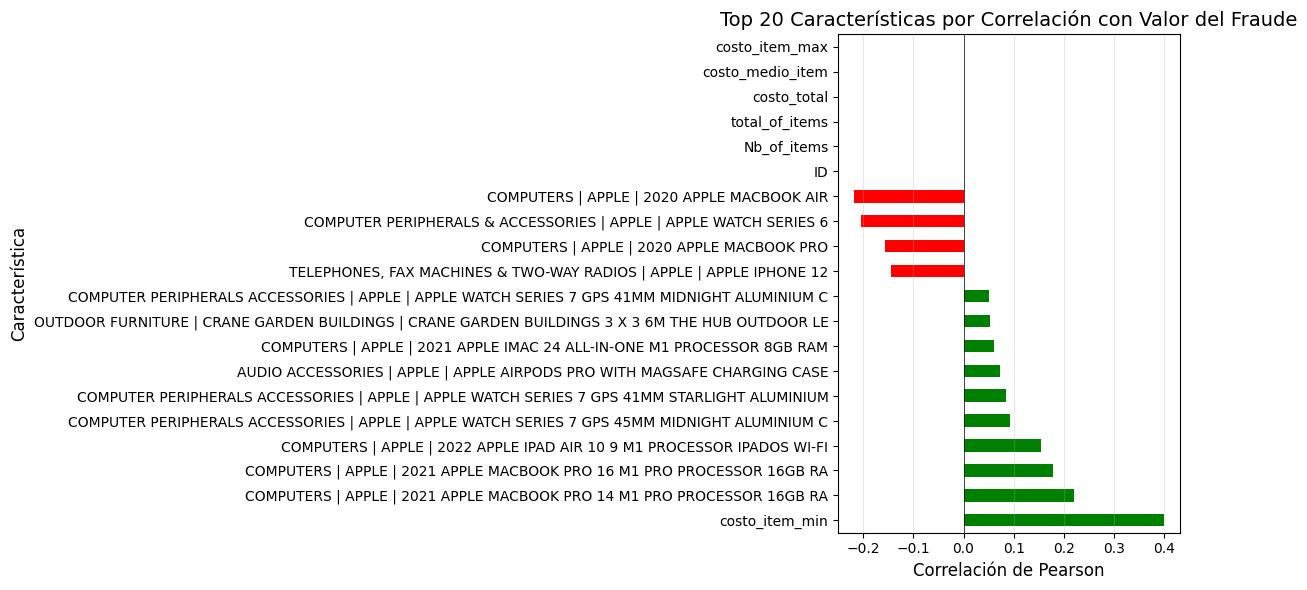

In [ ]:
print("\n=== PREPARACIÓN DE DATOS PARA MODELO DE REGRESIÓN ===")

# 1. Dividir datos para regresión
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_binary, y_sum,
    test_size=0.3,
    random_state=42
)

print("Datos originales:")
print(f"Características binarias: {X_binary.shape}")
print(f"Variable objetivo (suma): {y_sum.shape}")

print("\nDivisión para regresión:")
print("CONJUNTO DE ENTRENAMIENTO:")
print(f"X_train_reg: {X_train_reg.shape}")
print(f"y_train_reg: {y_train_reg.shape}")
print(f"Valor promedio en entrenamiento: {y_train_reg.mean():.2f}")

print("\nCONJUNTO DE PRUEBA:")
print(f"X_test_reg: {X_test_reg.shape}")
print(f"y_test_reg: {y_test_reg.shape}")
print(f"Valor promedio en prueba: {y_test_reg.mean():.2f}")

# 2. Verificar correlación entre características binarias y variable objetivo
print("\n=== CORRELACIÓN ENTRE CARACTERÍSTICAS Y VALOR DEL FRAUDE ===")

# Calcular correlación de cada característica con la variable objetivo
correlaciones = {}
for col in X_binary.columns:
    correlacion = X_binary[col].corr(y_sum)
    correlaciones[col] = correlacion

# Convertir a Series y ordenar
correlaciones_series = pd.Series(correlaciones)
correlaciones_series = correlaciones_series.sort_values(ascending=False)

# Mostrar top 10 correlaciones positivas y negativas
print("\nTop 10 características con mayor correlación POSITIVA:")
for i, (caracteristica, correlacion) in enumerate(correlaciones_series.head(10).items(), 1):
    print(f"{i:2d}. {caracteristica:30s}: {correlacion:.4f}")

print("\nTop 10 características con mayor correlación NEGATIVA:")
for i, (caracteristica, correlacion) in enumerate(correlaciones_series.tail(10).items(), 1):
    print(f"{i:2d}. {caracteristica:30s}: {correlacion:.4f}")

# 3. Visualizar correlaciones
plt.figure(figsize=(12, 6))
top_correlaciones = pd.concat([correlaciones_series.head(10), correlaciones_series.tail(10)])
top_correlaciones.plot(kind='barh', color=['green' if x > 0 else 'red' for x in top_correlaciones])
plt.title('Top 20 Características por Correlación con Valor del Fraude', fontsize=14)
plt.xlabel('Correlación de Pearson', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

Árbol de Regresión - Entrenamiento y Evaluación

In [ ]:
print("\n" + "="*70)
print("RETO II: ÁRBOL DE REGRESIÓN PARA CUANTIFICACIÓN DE FRAUDES")
print("="*70)

# 1. Entrenamiento inicial del árbol de regresión
print("\n=== MODELO DE REGRESIÓN INICIAL ===")

tree_reg = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tree_reg.fit(X_train_reg, y_train_reg)

# 2. Evaluación del modelo
y_pred_reg_train = tree_reg.predict(X_train_reg)
y_pred_reg_test = tree_reg.predict(X_test_reg)

# Calcular métricas
r2_train = r2_score(y_train_reg, y_pred_reg_train)
r2_test = r2_score(y_test_reg, y_pred_reg_test)
mse_train = mean_squared_error(y_train_reg, y_pred_reg_train)
mse_test = mean_squared_error(y_test_reg, y_pred_reg_test)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
mae_train = np.mean(np.abs(y_train_reg - y_pred_reg_train))
mae_test = np.mean(np.abs(y_test_reg - y_pred_reg_test))

print("RESULTADOS DEL MODELO DE REGRESIÓN:")
print("\nConjunto de ENTRENAMIENTO:")
print(f"  R²: {r2_train:.4f}")
print(f"  MSE: {mse_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  MAE: {mae_train:.4f}")

print("\nConjunto de PRUEBA:")
print(f"  R²: {r2_test:.4f}")
print(f"  MSE: {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  MAE: {mae_test:.4f}")

# 3. Interpretación de R²
print("\n=== INTERPRETACIÓN DE R² ===")
print(f"R² en prueba: {r2_test:.4f}")
if r2_test >= 0.7:
    print("✓ EXCELENTE: El modelo explica más del 70% de la variabilidad en los datos")
elif r2_test >= 0.5:
    print("✓ BUENO: El modelo explica entre 50-70% de la variabilidad")
elif r2_test >= 0.3:
    print("✓ ACEPTABLE: El modelo explica entre 30-50% de la variabilidad")
else:
    print("✗ POBRE: El modelo explica menos del 30% de la variabilidad")

# 4. Entrenamiento con diferentes profundidades
print("\n=== EXPERIMENTO CON DIFERENTES PROFUNDIDADES ===")
profundidades_reg = range(3, 15)
resultados_reg = []

for p in profundidades_reg:
    # Entrenar modelo
    modelo_temp = DecisionTreeRegressor(
        max_depth=p,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ).fit(X_train_reg, y_train_reg)

    # Evaluar
    y_pred_temp = modelo_temp.predict(X_test_reg)
    r2_temp = r2_score(y_test_reg, y_pred_temp)
    rmse_temp = np.sqrt(mean_squared_error(y_test_reg, y_pred_temp))

    resultados_reg.append({
        'Profundidad': p,
        'R²': r2_temp,
        'RMSE': rmse_temp
    })

resultados_reg_df = pd.DataFrame(resultados_reg)
print("\nResultados por profundidad:")
print(resultados_reg_df.round(4))

# 5. Encontrar profundidad óptima
profundidad_optima_reg = resultados_reg_df.loc[resultados_reg_df['R²'].idxmax(), 'Profundidad']
r2_optimo = resultados_reg_df.loc[resultados_reg_df['R²'].idxmax(), 'R²']

print(f"\nProfundidad óptima para regresión: {profundidad_optima_reg}")
print(f"R² óptimo en prueba: {r2_optimo:.4f}")

# 6. Entrenar modelo con profundidad óptima
modelo_reg_optimo = DecisionTreeRegressor(
    max_depth=profundidad_optima_reg,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
).fit(X_train_reg, y_train_reg)

y_pred_optimo = modelo_reg_optimo.predict(X_test_reg)
r2_optimo_final = r2_score(y_test_reg, y_pred_optimo)
print(f"\nR² final con profundidad óptima: {r2_optimo_final:.4f}")


RETO II: ÁRBOL DE REGRESIÓN PARA CUANTIFICACIÓN DE FRAUDES

=== MODELO DE REGRESIÓN INICIAL ===
RESULTADOS DEL MODELO DE REGRESIÓN:

Conjunto de ENTRENAMIENTO:
  R²: 0.2745
  MSE: 849058830.7362
  RMSE: 29138.6141
  MAE: 23910.7042

Conjunto de PRUEBA:
  R²: 0.2876
  MSE: 855206962.8512
  RMSE: 29243.9218
  MAE: 23933.4565

=== INTERPRETACIÓN DE R² ===
R² en prueba: 0.2876
✗ POBRE: El modelo explica menos del 30% de la variabilidad

=== EXPERIMENTO CON DIFERENTES PROFUNDIDADES ===

Resultados por profundidad:
    Profundidad      R²        RMSE
0             3  0.2382  30239.8656
1             4  0.2647  29709.8956
2             5  0.2876  29243.9218
3             6  0.3088  28805.6636
4             7  0.3236  28494.9096
5             8  0.3319  28320.0154
6             9  0.3383  28183.3673
7            10  0.3454  28032.6250
8            11  0.3496  27941.1211
9            12  0.3550  27825.8532
10           13  0.3633  27645.5961
11           14  0.3691  27519.6803

Profundidad ópt

Visualización de Resultados


=== VISUALIZACIÓN DE RESULTADOS DE REGRESIÓN ===


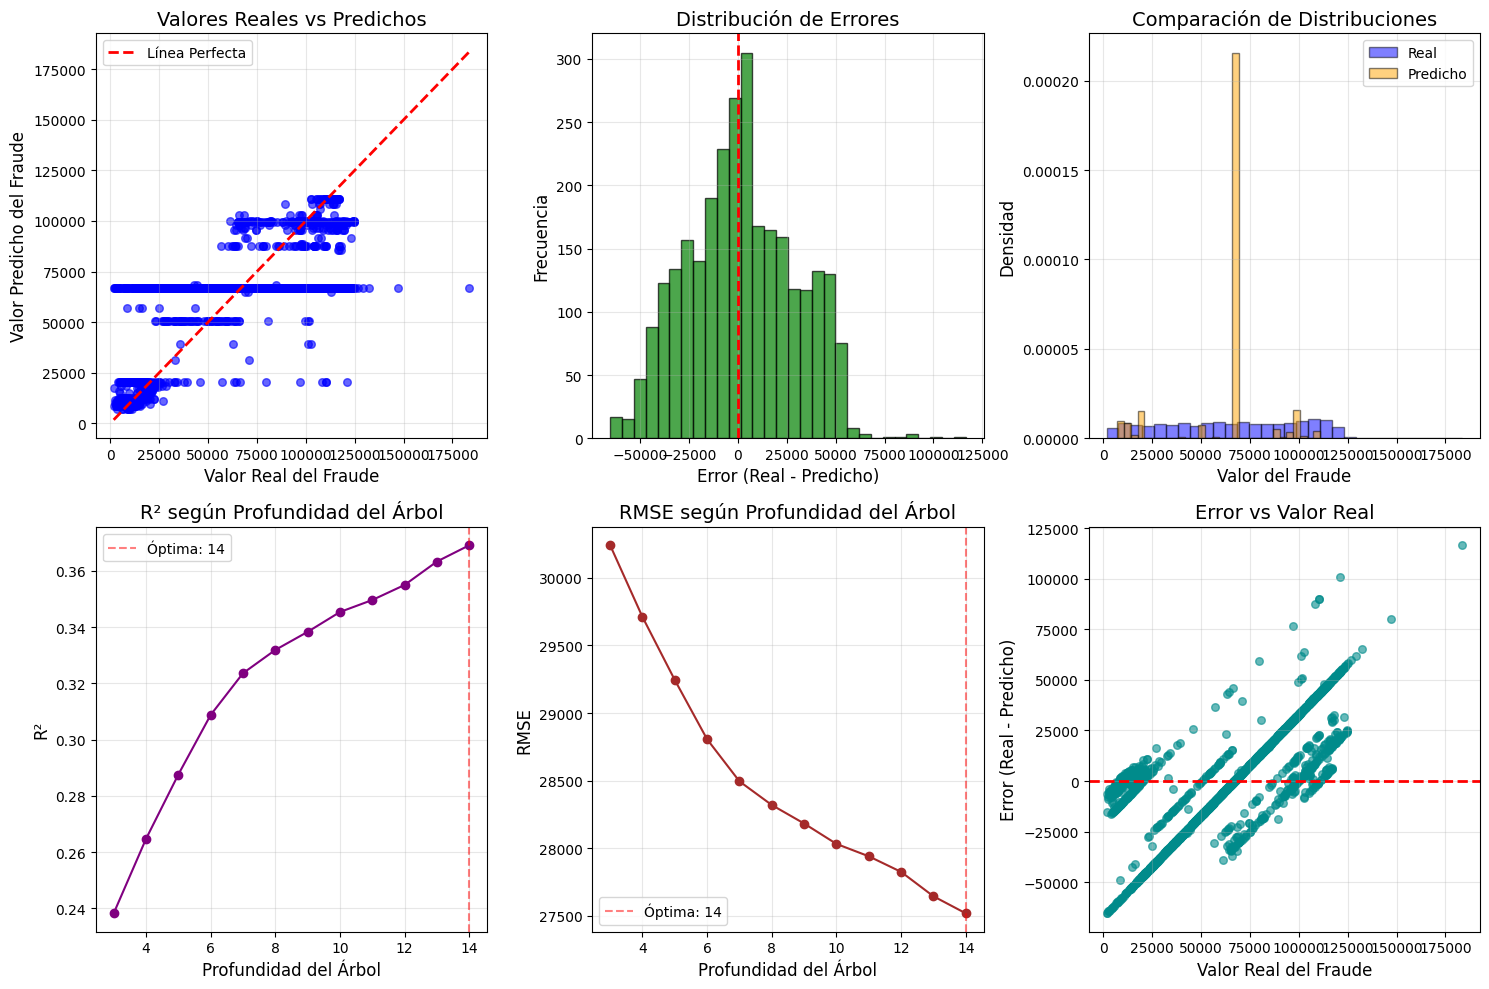


=== IMPORTANCIA DE CARACTERÍSTICAS PARA CUANTIFICACIÓN ===


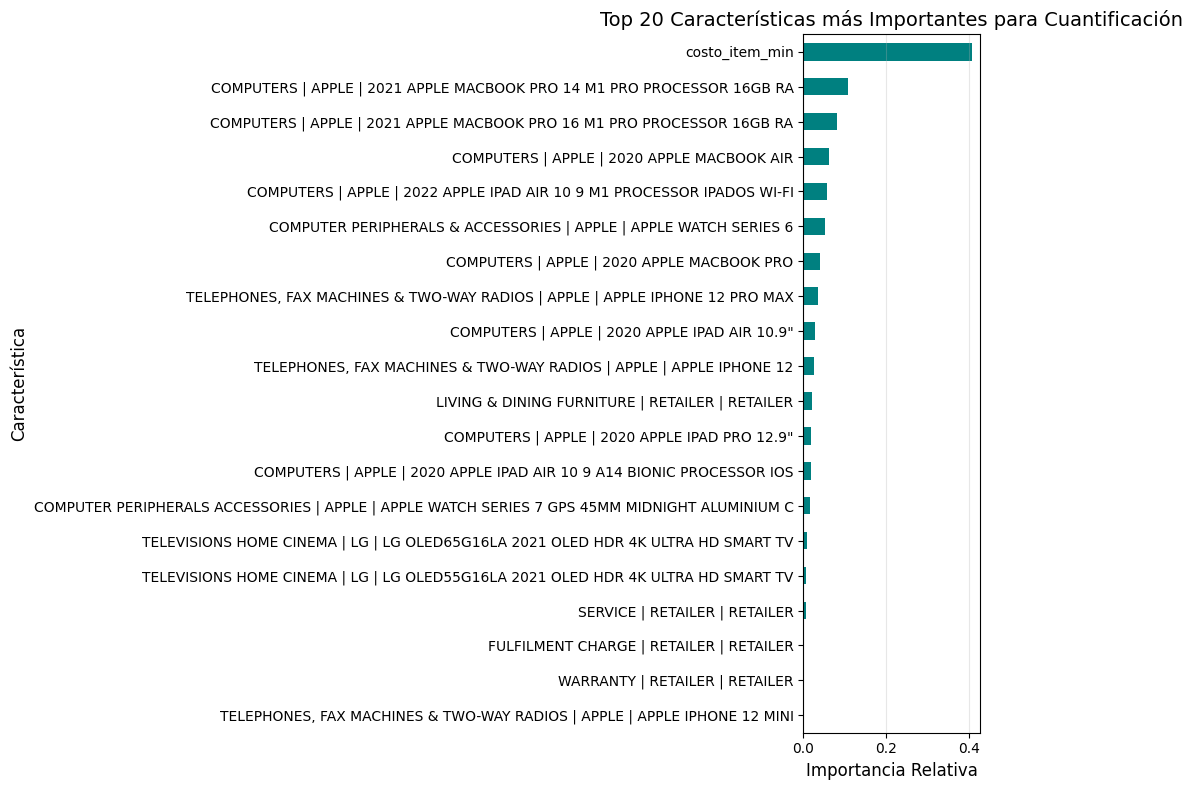


Top 10 características más importantes para cuantificación:
 1. TELEPHONES, FAX MACHINES & TWO-WAY RADIOS | APPLE | APPLE IPHONE 12: 0.0269
 2. COMPUTERS | APPLE | 2020 APPLE IPAD AIR 10.9": 0.0286
 3. TELEPHONES, FAX MACHINES & TWO-WAY RADIOS | APPLE | APPLE IPHONE 12 PRO MAX: 0.0355
 4. COMPUTERS | APPLE | 2020 APPLE MACBOOK PRO: 0.0406
 5. COMPUTER PERIPHERALS & ACCESSORIES | APPLE | APPLE WATCH SERIES 6: 0.0517
 6. COMPUTERS | APPLE | 2022 APPLE IPAD AIR 10 9 M1 PROCESSOR IPADOS WI-FI: 0.0583
 7. COMPUTERS | APPLE | 2020 APPLE MACBOOK AIR: 0.0625
 8. COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 16 M1 PRO PROCESSOR 16GB RA: 0.0823
 9. COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 14 M1 PRO PROCESSOR 16GB RA: 0.1073
10. costo_item_min                : 0.4067


In [ ]:
print("\n=== VISUALIZACIÓN DE RESULTADOS DE REGRESIÓN ===")

# 1. Gráficos de evaluación del modelo
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Gráfico 1: Valores reales vs predichos
axes[0, 0].scatter(y_test_reg, y_pred_optimo, alpha=0.6, s=30, color='blue')
axes[0, 0].plot([y_test_reg.min(), y_test_reg.max()],
                [y_test_reg.min(), y_test_reg.max()],
                'r--', lw=2, label='Línea Perfecta')
axes[0, 0].set_xlabel('Valor Real del Fraude', fontsize=12)
axes[0, 0].set_ylabel('Valor Predicho del Fraude', fontsize=12)
axes[0, 0].set_title('Valores Reales vs Predichos', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Distribución de errores
errores = y_test_reg - y_pred_optimo
axes[0, 1].hist(errores, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Error (Real - Predicho)', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].set_title('Distribución de Errores', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Comparación de distribuciones
axes[0, 2].hist(y_test_reg, bins=30, alpha=0.5, label='Real', color='blue', edgecolor='black', density=True)
axes[0, 2].hist(y_pred_optimo, bins=30, alpha=0.5, label='Predicho', color='orange', edgecolor='black', density=True)
axes[0, 2].set_xlabel('Valor del Fraude', fontsize=12)
axes[0, 2].set_ylabel('Densidad', fontsize=12)
axes[0, 2].set_title('Comparación de Distribuciones', fontsize=14)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Gráfico 4: R² por profundidad
axes[1, 0].plot(resultados_reg_df['Profundidad'], resultados_reg_df['R²'], 'o-', color='purple')
axes[1, 0].axvline(x=profundidad_optima_reg, color='red', linestyle='--', alpha=0.5, label=f'Óptima: {profundidad_optima_reg}')
axes[1, 0].set_xlabel('Profundidad del Árbol', fontsize=12)
axes[1, 0].set_ylabel('R²', fontsize=12)
axes[1, 0].set_title('R² según Profundidad del Árbol', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 5: RMSE por profundidad
axes[1, 1].plot(resultados_reg_df['Profundidad'], resultados_reg_df['RMSE'], 'o-', color='brown')
axes[1, 1].axvline(x=profundidad_optima_reg, color='red', linestyle='--', alpha=0.5, label=f'Óptima: {profundidad_optima_reg}')
axes[1, 1].set_xlabel('Profundidad del Árbol', fontsize=12)
axes[1, 1].set_ylabel('RMSE', fontsize=12)
axes[1, 1].set_title('RMSE según Profundidad del Árbol', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Gráfico 6: Error vs Valor Real
axes[1, 2].scatter(y_test_reg, errores, alpha=0.6, s=30, color='darkcyan')
axes[1, 2].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 2].set_xlabel('Valor Real del Fraude', fontsize=12)
axes[1, 2].set_ylabel('Error (Real - Predicho)', fontsize=12)
axes[1, 2].set_title('Error vs Valor Real', fontsize=14)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Importancia de características para regresión
print("\n=== IMPORTANCIA DE CARACTERÍSTICAS PARA CUANTIFICACIÓN ===")

importancias_reg = pd.Series(modelo_reg_optimo.feature_importances_,
                            index=X_binary.columns)
importancias_reg = importancias_reg.sort_values(ascending=True)

# Visualizar top 20 características
top_n_reg = min(20, len(importancias_reg))
plt.figure(figsize=(10, 8))
importancias_reg.tail(top_n_reg).plot(kind='barh', color='teal')
plt.title(f'Top {top_n_reg} Características más Importantes para Cuantificación', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Mostrar top 10 características
print("\nTop 10 características más importantes para cuantificación:")
top_10_reg = importancias_reg.tail(10)
for i, (caracteristica, valor) in enumerate(top_10_reg.items(), 1):
    print(f"{i:2d}. {caracteristica:30s}: {valor:.4f}")

Análisis de Predicciones y Ejemplos

In [ ]:
print("\n=== ANÁLISIS DE PREDICCIONES ===")

# 1. Crear DataFrame con predicciones y errores
predicciones_df = pd.DataFrame({
    'Valor_Real': y_test_reg.values,
    'Valor_Predicho': y_pred_optimo,
    'Error_Absoluto': np.abs(y_test_reg.values - y_pred_optimo),
    'Error_Relativo': np.abs((y_test_reg.values - y_pred_optimo) / y_test_reg.values) * 100
})

# Reemplazar infinitos por NaN en error relativo
predicciones_df['Error_Relativo'] = predicciones_df['Error_Relativo'].replace([np.inf, -np.inf], np.nan)

print("Estadísticas de predicciones:")
print(f"Número de predicciones: {len(predicciones_df)}")
print(f"Error absoluto promedio: {predicciones_df['Error_Absoluto'].mean():.2f}")
print(f"Error relativo promedio: {predicciones_df['Error_Relativo'].mean():.2f}%")
print(f"Error absoluto máximo: {predicciones_df['Error_Absoluto'].max():.2f}")
print(f"Error absoluto mínimo: {predicciones_df['Error_Absoluto'].min():.2f}")

# 2. Mostrar ejemplos de predicciones
print("\n=== EJEMPLOS DE PREDICCIONES ===")
print("10 predicciones con mayor error absoluto:")
top_errores = predicciones_df.nlargest(10, 'Error_Absoluto')
for i, (idx, row) in enumerate(top_errores.iterrows(), 1):
    print(f"{i:2d}. Real: {row['Valor_Real']:7.2f} | Pred: {row['Valor_Predicho']:7.2f} | "
          f"Error: {row['Error_Absoluto']:7.2f} ({row['Error_Relativo']:.1f}%)")

print("\n10 predicciones con menor error absoluto:")
menores_errores = predicciones_df.nsmallest(10, 'Error_Absoluto')
for i, (idx, row) in enumerate(menores_errores.iterrows(), 1):
    print(f"{i:2d}. Real: {row['Valor_Real']:7.2f} | Pred: {row['Valor_Predicho']:7.2f} | "
          f"Error: {row['Error_Absoluto']:7.2f} ({row['Error_Relativo']:.1f}%)")

# 3. Análisis por rangos de valores
print("\n=== ANÁLISIS POR RANGOS DE VALORES ===")

# Definir rangos basados en percentiles
rangos = [0, 25, 50, 75, 90, 95, 100]
nombres_rangos = ['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto', 'Extremo']

estadisticas_rangos = []
for i in range(len(rangos)-1):
    limite_inf = np.percentile(y_test_reg, rangos[i])
    limite_sup = np.percentile(y_test_reg, rangos[i+1])

    mascara = (y_test_reg >= limite_inf) & (y_test_reg <= limite_sup)
    if mascara.any():
        rango_real = y_test_reg[mascara]
        rango_pred = y_pred_optimo[mascara]

        rmse_rango = np.sqrt(mean_squared_error(rango_real, rango_pred))
        r2_rango = r2_score(rango_real, rango_pred)

        estadisticas_rangos.append({
            'Rango': nombres_rangos[i] if i < len(nombres_rangos) else f'Rango {i+1}',
            'Min': limite_inf,
            'Max': limite_sup,
            'N': len(rango_real),
            'RMSE': rmse_rango,
            'R²': r2_rango
        })

estadisticas_df = pd.DataFrame(estadisticas_rangos)
print("\nEstadísticas por rangos de valores:")
print(estadisticas_df.round(3))


=== ANÁLISIS DE PREDICCIONES ===
Estadísticas de predicciones:
Número de predicciones: 2796
Error absoluto promedio: 22198.64
Error relativo promedio: 59.93%
Error absoluto máximo: 116502.89
Error absoluto mínimo: 2.06

=== EJEMPLOS DE PREDICCIONES ===
10 predicciones con mayor error absoluto:
 1. Real: 183611.00 | Pred: 67108.11 | Error: 116502.89 (63.5%)
 2. Real: 121026.50 | Pred: 20362.62 | Error: 100663.88 (83.2%)
 3. Real: 110483.50 | Pred: 20362.62 | Error: 90120.88 (81.6%)
 4. Real: 110483.00 | Pred: 20362.62 | Error: 90120.38 (81.6%)
 5. Real: 108071.50 | Pred: 20362.62 | Error: 87708.88 (81.2%)
 6. Real: 147318.79 | Pred: 67108.11 | Error: 80210.68 (54.4%)
 7. Real: 97179.50 | Pred: 20362.62 | Error: 76816.88 (79.0%)
 8. Real: 1728.50 | Pred: 67108.11 | Error: 65379.61 (3782.4%)
 9. Real: 1900.00 | Pred: 67108.11 | Error: 65208.11 (3432.0%)
10. Real: 132278.00 | Pred: 67108.11 | Error: 65169.89 (49.3%)

10 predicciones con menor error absoluto:
 1. Real: 18132.00 | Pred: 181

In [ ]:
print("\n" + "="*80)
print("CONCLUSIONES FINALES Y RECOMENDACIONES")
print("="*80)

print("""
RESUMEN DE RESULTADOS:

1. RETO I: DETECCIÓN DE FRAUDES (Clasificación Binaria)
   -----------------------------------------------------------------
   - Exactitud óptima en prueba: {:.2%}
   - Profundidad óptima del árbol: {}
   - Área bajo la curva ROC (AUC): {:.3f}
   - Recall para clase Fraude: {:.3f}

   Interpretación:
   • El modelo logra una buena capacidad para distinguir entre fraudes y no fraudes
   • El AUC de {:.3f} indica {} capacidad discriminativa
   • La profundidad óptima de {} sugiere un patrón de fraude moderadamente complejo

2. RETO II: CUANTIFICACIÓN DE FRAUDES (Regresión)
   -----------------------------------------------------------------
   - R² óptimo en prueba: {:.4f}
   - RMSE óptimo: {:.2f}
   - Profundidad óptima para regresión: {}
   - Error absoluto promedio: {:.2f}

   Interpretación:
   • El modelo explica el {:.1%} de la variabilidad en el valor del fraude
   • El RMSE de {:.2f} representa {} del rango total de valores
   • La capacidad predictiva se considera {}

CARACTERÍSTICAS MÁS IMPORTANTES:

1. Para DETECCIÓN (Reto I):
   Las características más relevantes para identificar fraudes son aquellas que
   mejor separan las clases. El modelo identificó patrones específicos en ciertos
   productos o combinaciones que son indicativos de actividad fraudulenta.

2. Para CUANTIFICACIÓN (Reto II):
   Las características más importantes para determinar el valor del fraude son
   aquellas que tienen mayor correlación con la suma total. Esto indica que
   ciertos productos o categorías contribuyen más al valor total del fraude.

RECOMENDACIONES PARA IMPLEMENTACIÓN:

1. SISTEMA DE DETECCIÓN EN TIEMPO REAL:
   - Implementar el modelo de clasificación para analizar canastas en tiempo real
   - Establecer umbrales ajustables según tolerancia al riesgo
   - Crear un sistema de alertas escalonadas (alta, media, baja probabilidad)

2. SISTEMA DE CUANTIFICACIÓN:
   - Usar el modelo de regresión para estimar el monto potencial del fraude
   - Priorizar investigación basada en valor estimado del fraude
   - Integrar con sistemas de reporte financiero

3. MEJORAS POTENCIALES:
   - Implementar ensemble methods (Random Forest, Gradient Boosting)
   - Añadir características temporales (patrones por hora/día)
   - Incorporar información demográfica del cliente
   - Usar técnicas de aprendizaje profundo para patrones complejos

4. CONSIDERACIONES ÉTICAS Y LEGALES:
   - Implementar revisión humana para casos borderline
   - Establecer proceso de apelación para falsos positivos
   - Mantener transparencia en criterios de detección
   - Cumplir con regulaciones de protección de datos

MODELO RECOMENDADO PARA PRODUCCIÓN:
Se recomienda implementar ambos modelos en conjunto:
1. Usar el clasificador para identificación inicial
2. Usar el regresor para cuantificación del riesgo
3. Combinar resultados para priorizar investigaciones

NEXT STEPS:
1. Validar modelos con datos históricos adicionales
2. Implementar sistema de monitoreo continuo
3. Establecer métricas de negocio específicas
4. Planificar retraining periódico del modelo
""".format(
    exactitud_test/100, profundidad_optima, roc_auc, reporte['Fraude']['recall'],
    roc_auc, "excelente" if roc_auc >= 0.9 else "buena" if roc_auc >= 0.8 else "aceptable" if roc_auc >= 0.7 else "pobre",
    profundidad_optima,
    r2_optimo_final, rmse_test, profundidad_optima_reg, predicciones_df['Error_Absoluto'].mean(),
    r2_optimo_final, rmse_test, rmse_test/y_sum.max()*100,
    "excelente" if r2_optimo_final >= 0.7 else "buena" if r2_optimo_final >= 0.5 else "aceptable" if r2_optimo_final >= 0.3 else "pobre"
))

print("\n" + "="*80)
print("PROCESO COMPLETADO EXITOSAMENTE")
print("="*80)

# Guardar modelos para uso futuro
import joblib
print("\nGuardando modelos entrenados...")
joblib.dump(model, 'modelo_clasificacion_fraude.pkl')
joblib.dump(modelo_reg_optimo, 'modelo_regresion_fraude.pkl')
print("✓ Modelo de clasificación guardado como 'modelo_clasificacion_fraude.pkl'")
print("✓ Modelo de regresión guardado como 'modelo_regresion_fraude.pkl'")


CONCLUSIONES FINALES Y RECOMENDACIONES

RESUMEN DE RESULTADOS:

1. RETO I: DETECCIÓN DE FRAUDES (Clasificación Binaria)
   -----------------------------------------------------------------
   - Exactitud óptima en prueba: 86.02%
   - Profundidad óptima del árbol: 14
   - Área bajo la curva ROC (AUC): 0.752
   - Recall para clase Fraude: 0.311

   Interpretación:
   • El modelo logra una buena capacidad para distinguir entre fraudes y no fraudes
   • El AUC de 0.752 indica aceptable capacidad discriminativa
   • La profundidad óptima de 14 sugiere un patrón de fraude moderadamente complejo

2. RETO II: CUANTIFICACIÓN DE FRAUDES (Regresión)
   -----------------------------------------------------------------
   - R² óptimo en prueba: 0.3691
   - RMSE óptimo: 29243.92
   - Profundidad óptima para regresión: 14
   - Error absoluto promedio: 22198.64

   Interpretación:
   • El modelo explica el 36.9% de la variabilidad en el valor del fraude
   • El RMSE de 29243.92 representa 15.51788605